In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df = pd.read_csv('dvf_final_2020_2025.csv', low_memory=False)

# Aperçu rapide
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 5828160 entries, 0 to 5828159
Data columns (total 22 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   id_mutation                str    
 1   date_mutation              str    
 2   annee                      int64  
 3   mois                       int64  
 4   nature_mutation            str    
 5   valeur_fonciere            float64
 6   surface_reelle_bati        float64
 7   prix_m2                    float64
 8   type_local                 str    
 9   nombre_pieces_principales  float64
 10  pieces_renseignees         bool   
 11  surface_terrain            float64
 12  code_departement           str    
 13  code_commune               str    
 14  nom_commune                str    
 15  code_postal                float64
 16  adresse_numero             float64
 17  adresse_nom_voie           str    
 18  adresse_complete           str    
 19  longitude                  float64
 20  latitude     

In [38]:
print(df.isna().sum().sort_values(ascending=False))

surface_terrain              2271912
latitude                      104520
longitude                     104520
adresse_numero                 70060
code_postal                      303
adresse_nom_voie                 201
valeur_fonciere                    0
nature_mutation                    0
mois                               0
annee                              0
date_mutation                      0
id_mutation                        0
type_local                         0
surface_reelle_bati                0
code_commune                       0
code_departement                   0
pieces_renseignees                 0
nombre_pieces_principales          0
prix_m2                            0
nom_commune                        0
adresse_complete                   0
coordonnees_disponibles            0
dtype: int64


# Vérification fichier dvf_final_2020_2025.csv
Le nettoyage (supprimer les lignes aberrantes) se fait Avant le split. L'encodage (transformer du texte en chiffres) se fait souvent Après le split pour éviter que des informations du set de test ne "fuient" dans le set d'entraînement

## 1. id_mutation

In [39]:
# Vérification du nombre de valeurs uniques par rapport au nombre de lignes
n_uniques = df['id_mutation'].nunique()
n_total = len(df)

print(f"Valeurs uniques : {n_uniques}")
print(f"Nombre de lignes : {n_total}")
print(f"Différence : {n_total - n_uniques}")

Valeurs uniques : 4764573
Nombre de lignes : 5828160
Différence : 1063587


In [40]:
# 1. On identifie les id_mutation qui apparaissent plus d'une fois
v_counts = df['id_mutation'].value_counts()
ids_doublons = v_counts[v_counts > 1].index

# 2. On prend un échantillon de ces doublons (ex: les 1000 premiers) pour l'analyse
df_check = df[df['id_mutation'].isin(ids_doublons[:1000])]

# 3. On calcule combien de prix différents il y a par id_mutation
prix_par_mutation = df_check.groupby('id_mutation')['valeur_fonciere'].nunique()

print(f"Sur l'échantillon de doublons :")
print(f"- Mutations avec un prix identique sur toutes les lignes : {(prix_par_mutation == 1).sum()}")
print(f"- Mutations avec des prix différents selon les lignes : {(prix_par_mutation > 1).sum()}")

# 4. Visualisons un exemple concret pour confirmer
df[df['id_mutation'].isin(ids_doublons[:1])].sort_values('id_mutation')

Sur l'échantillon de doublons :
- Mutations avec un prix identique sur toutes les lignes : 1000
- Mutations avec des prix différents selon les lignes : 0


,id_mutation,date_mutation,annee,mois,nature_mutation,valeur_fonciere,surface_reelle_bati,prix_m2,type_local,nombre_pieces_principales,...,code_departement,code_commune,nom_commune,code_postal,adresse_numero,adresse_nom_voie,adresse_complete,longitude,latitude,coordonnees_disponibles
3669793,2023-280081,2023-02-06,2023,2,Vente,1643439.6,68.0,24168.229412,Appartement,3.0,...,25,25056,Besançon,25000.0,13.0,RUE DU GENERAL BRULARD,13.0 RUE DU GENERAL BRULARD 25000.0 Besançon,6.006206,47.22799,True
3670547,2023-280081,2023-02-06,2023,2,Vente,1643439.6,61.0,26941.632787,Appartement,3.0,...,25,25056,Besançon,25000.0,13.0,RUE DU GENERAL BRULARD,13.0 RUE DU GENERAL BRULARD 25000.0 Besançon,6.006206,47.22799,True
3670548,2023-280081,2023-02-06,2023,2,Vente,1643439.6,58.0,28335.165517,Appartement,3.0,...,25,25056,Besançon,25000.0,13.0,RUE DU GENERAL BRULARD,13.0 RUE DU GENERAL BRULARD 25000.0 Besançon,6.006206,47.22799,True
3670549,2023-280081,2023-02-06,2023,2,Vente,1643439.6,70.0,23477.708571,Appartement,4.0,...,25,25056,Besançon,25000.0,13.0,RUE DU GENERAL BRULARD,13.0 RUE DU GENERAL BRULARD 25000.0 Besançon,6.006206,47.22799,True
3670550,2023-280081,2023-02-06,2023,2,Vente,1643439.6,58.0,28335.165517,Appartement,3.0,...,25,25056,Besançon,25000.0,13.0,RUE DU GENERAL BRULARD,13.0 RUE DU GENERAL BRULARD 25000.0 Besançon,6.006206,47.22799,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3670173,2023-280081,2023-02-06,2023,2,Vente,1643439.6,82.0,20041.946341,Appartement,4.0,...,25,25056,Besançon,25000.0,13.0,RUE DU GENERAL BRULARD,13.0 RUE DU GENERAL BRULARD 25000.0 Besançon,6.006206,47.22799,True
3670172,2023-280081,2023-02-06,2023,2,Vente,1643439.6,82.0,20041.946341,Appartement,4.0,...,25,25056,Besançon,25000.0,13.0,RUE DU GENERAL BRULARD,13.0 RUE DU GENERAL BRULARD 25000.0 Besançon,6.006206,47.22799,True
3670171,2023-280081,2023-02-06,2023,2,Vente,1643439.6,82.0,20041.946341,Appartement,4.0,...,25,25056,Besançon,25000.0,13.0,RUE DU GENERAL BRULARD,13.0 RUE DU GENERAL BRULARD 25000.0 Besançon,6.006206,47.22799,True
3670177,2023-280081,2023-02-06,2023,2,Vente,1643439.6,88.0,18675.450000,Appartement,5.0,...,25,25056,Besançon,25000.0,13.0,RUE DU GENERAL BRULARD,13.0 RUE DU GENERAL BRULARD 25000.0 Besançon,6.006206,47.22799,True


In [41]:
# 1. Vérification des valeurs manquantes
null_ids = df['id_mutation'].isna().sum()

# 2. Comptage des transactions uniques vs lignes totales
total_lignes = len(df)
nb_uniques = df['id_mutation'].nunique()
ratio_doublons = (total_lignes - nb_uniques) / total_lignes * 100

# 3. Analyse du nombre de lots par transaction
lots_par_mutation = df.groupby('id_mutation').size()

print(f"--- Audit id_mutation ---")
print(f"Nombre total de lignes : {total_lignes}")
print(f"Nombre de mutations uniques : {nb_uniques}")
print(f"Valeurs manquantes : {null_ids}")
print(f"Pourcentage de lignes 'multi-lots' : {ratio_doublons:.2f}%")
print(f"\nNombre max de lots pour une seule vente : {lots_par_mutation.max()}")
print(f"Nombre moyen de lots par vente : {lots_par_mutation.mean():.2f}")

--- Audit id_mutation ---
Nombre total de lignes : 5828160
Nombre de mutations uniques : 4764573
Valeurs manquantes : 0
Pourcentage de lignes 'multi-lots' : 18.25%

Nombre max de lots pour une seule vente : 1146
Nombre moyen de lots par vente : 1.22


## 1.2 Synthèse du regroupement par mutation
* **Diagnostic** : 18,25% des lignes sont des composantes de transactions multi-lots (moyenne de 1,22 ligne par vente).
* **Traitement** : Fusion des lignes par `id_mutation` pour obtenir une observation unique par transaction.
* **Intégrité** : Les caractéristiques physiques (surfaces, pièces) sont sommées, tandis que les métadonnées (date, nature, année) sont préservées via la règle `first`.

1.3 Analyse de la cohérence des types lors de l'agrégation
L'agrégation par `id_mutation` nécessite une stratégie différenciée selon la nature des données :
* **Variables additives** : Les surfaces (`bati`, `terrain`) et le `nombre_pieces_principales` sont sommés pour représenter l'unité foncière globale.
* **Variables invariantes** : Les données géographiques (`longitude`, `code_commune`), temporelles (`date_mutation`) et la `valeur_fonciere` sont récupérées via la règle `first` ou `max` car elles sont identiques pour toutes les lignes d'une même mutation.
* **Variables calculées** : Le `prix_m2` a été exclu de l'agrégation pour éviter des moyennes de ratios erronées. Il est recalculé post-agrégation sur la base de la valeur foncière totale et de la surface totale sommée.

In [42]:
# 1. Traitement des surfaces de terrain manquantes (essentiel pour la somme)
df['surface_terrain'] = df['surface_terrain'].fillna(0)

# 2. Suppression du prix_m2 (sera recalculé après pour être exact)
if 'prix_m2' in df.columns:
    df = df.drop(columns=['prix_m2'])

# 3. On s'assure que les types sont corrects pour le groupement
df['date_mutation'] = pd.to_datetime(df['date_mutation'])
df['code_departement'] = df['code_departement'].astype(str)

In [43]:
agg_rules = {
    # On SOMME ce qui définit la taille globale du bien
    'surface_reelle_bati': 'sum',
    'nombre_pieces_principales': 'sum',
    'surface_terrain': 'sum',
    
    # On prend le MAXIMUM pour la valeur (car elle est répétée sur chaque ligne)
    'valeur_fonciere': 'max',
    
    # On garde la PREMIÈRE valeur pour tout le reste (invariants par mutation)
    'date_mutation': 'first',
    'annee': 'first',
    'mois': 'first',
    'nature_mutation': 'first',
    'type_local': 'first',
    'pieces_renseignees': 'first',
    'code_departement': 'first',
    'code_commune': 'first',
    'nom_commune': 'first',
    'code_postal': 'first',
    'adresse_numero': 'first',
    'adresse_nom_voie': 'first',
    'adresse_complete': 'first',
    'longitude': 'first',
    'latitude': 'first',
    'coordonnees_disponibles': 'first'
}

# Lancement de l'agrégation
df_clean = df.groupby('id_mutation').agg(agg_rules)

# Recalcul du prix_m2 propre
df_clean['prix_m2'] = df_clean['valeur_fonciere'] / df_clean['surface_reelle_bati']

###  Note sur l'index (id_mutation)
* **État actuel** : L'identifiant de mutation est devenu l'index du DataFrame suite à l'agrégation.
* **Rôle** : Il sert de clé unique pour identifier chaque transaction.
* **Usage ML** : Bien qu'essentiel pour la manipulation des données, cet index ne sera pas utilisé comme variable prédictive ("Feature") afin d'éviter tout risque de surapprentissage (overfitting).

In [44]:
# 1. Vérification des statistiques descriptives
print("--- Statistiques de contrôle ---")
display(df_clean[['valeur_fonciere', 'surface_reelle_bati', 'prix_m2']].describe())

# 2. Vérification des valeurs infinies (causées par division par 0 surface)
inf_prix = np.isinf(df_clean['prix_m2']).sum()
print(f"\nNombre de prix au m2 infinis (Surface 0) : {inf_prix}")

--- Statistiques de contrôle ---


,valeur_fonciere,surface_reelle_bati,prix_m2
count,4.764573e+06,4.764573e+06,4.764573e+06
mean,2.490829e+05,1.015395e+02,3.034496e+03
std,2.757712e+05,1.191188e+02,2.547866e+03
min,3.000000e+02,1.000000e+00,1.675361e+00
25%,1.170000e+05,5.500000e+01,1.405229e+03
50%,1.860000e+05,8.000000e+01,2.375000e+03
75%,2.950000e+05,1.150000e+02,3.797403e+03
max,4.650000e+07,8.633100e+04,3.000000e+04



Nombre de prix au m2 infinis (Surface 0) : 0


In [45]:
# Vérification du nom de l'index et de sa forme
print(f"Nom de l'index : {df_clean.index.name}")
print(f"Type de l'index : {type(df_clean.index)}")

# Affichage des premières lignes pour voir le décalage visuel (l'index est plus bas)
display(df_clean.head(2))

Nom de l'index : id_mutation
Type de l'index : <class 'pandas.Index'>


,surface_reelle_bati,nombre_pieces_principales,surface_terrain,valeur_fonciere,date_mutation,annee,mois,nature_mutation,type_local,pieces_renseignees,...,code_commune,nom_commune,code_postal,adresse_numero,adresse_nom_voie,adresse_complete,longitude,latitude,coordonnees_disponibles,prix_m2
id_mutation,,,,,,,,,,,,,,,,,,,,,
2020-100000,26.0,2.0,0.0,93300.0,2020-09-19,2020,9,Vente,Appartement,True,...,14724,Varaville,14390.0,5002.0,AV DU PRESIDENT COTY,5002.0 AV DU PRESIDENT COTY 14390.0 Varaville,-0.156799,49.283990,True,3588.461538
2020-100001,113.0,5.0,413.0,223000.0,2020-09-10,2020,9,Vente,Maison,True,...,14752,Villers-Bocage,14310.0,1.0,SQ DU PIC VERT,1.0 SQ DU PIC VERT 14310.0 Villers-Bocage,-0.654175,49.075644,True,1973.451327


In [46]:
# verification valeurs manquantes
print(df_clean.isna().sum().sort_values(ascending=False))

longitude                    68457
latitude                     68457
adresse_numero               62595
code_postal                    220
adresse_nom_voie               141
date_mutation                    0
valeur_fonciere                  0
surface_terrain                  0
nombre_pieces_principales        0
surface_reelle_bati              0
annee                            0
nature_mutation                  0
mois                             0
nom_commune                      0
code_commune                     0
code_departement                 0
pieces_renseignees               0
type_local                       0
adresse_complete                 0
coordonnees_disponibles          0
prix_m2                          0
dtype: int64


# Audit de complétude des données
L'analyse des valeurs manquantes post-agrégation révèle un dataset d'une très haute fiabilité :
* **Variables critiques** : Les variables cibles (prix) et les prédicteurs physiques (surfaces, pièces) présentent un taux de complétude de 100%.
* **Variables géographiques** : Seules les coordonnées de longitude et les numéros de voie présentent des manques mineurs (env. 1,4%), principalement liés à des transactions en zone rurale ou des nouvelles constructions non encore répertoriées.
* **Intégrité** : Le faible volume de données manquantes permet d'envisager une modélisation sans biais d'échantillonnage majeur.

## Longitude et Latitude
Décision : Suppression des 1,4 % de lignes manquantes (Listwise deletion).
Justification : Le faible volume de pertes ne justifie pas une imputation par commune qui biaiserait la précision géographique du modèle.
Rôle ML : Variables de localisation primaires. Elles permettront au modèle de capturer les disparités de prix régionales et locales (micro-marchés).

In [47]:
# 1. Suppression des lignes où les coordonnées manquent
print(f"Lignes avant : {len(df_clean)}")
df_clean = df_clean.dropna(subset=['longitude', 'latitude'])
print(f"Lignes après suppression des NaN géo : {len(df_clean)}")

# 2. Nettoyage des coordonnées aberrantes (0,0)
# Parfois les erreurs de saisie mettent 0 au lieu de NaN
df_clean = df_clean[(df_clean['longitude'] != 0) & (df_clean['latitude'] != 0)]

# 3. Suppression de la colonne 'coordonnees_disponibles'
# Maintenant qu'on a filtré, cette colonne booléenne n'apporte plus d'info au ML
df_clean = df_clean.drop(columns=['coordonnees_disponibles'])

Lignes avant : 4764573
Lignes après suppression des NaN géo : 4696116


## Suppression des variables d'adresse textuelles
* **Problématique** : Les adresses (numéro, voie, libellé complet) sont des chaînes de caractères non structurées.
* **Décision** : Suppression des colonnes `adresse_numero`, `adresse_nom_voie` et `adresse_complete`.
* **Justification** : 
    1. **Redondance** : L'information spatiale est déjà portée par le couple (Latitude, Longitude).
    2. **Complexité** : Le traitement par *Natural Language Processing* (NLP) de ces champs alourdirait inutilement le modèle sans gain de précision significatif.
    3. **Performance** : Réduction drastique du nombre de colonnes après encodage.

In [48]:
# 1. Liste des colonnes à supprimer car non exploitables ou redondantes
cols_to_drop = ['adresse_numero', 'adresse_nom_voie', 'adresse_complete']

# 2. Suppression effective
# On utilise errors='ignore' pour éviter une erreur si le code est relancé
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

# 3. Vérification de la structure restante
print(f"Nombre de colonnes restantes : {len(df_clean.columns)}")
print("Colonnes conservées pour la suite :")
print(df_clean.columns.tolist())

Nombre de colonnes restantes : 17
Colonnes conservées pour la suite :
['surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'valeur_fonciere', 'date_mutation', 'annee', 'mois', 'nature_mutation', 'type_local', 'pieces_renseignees', 'code_departement', 'code_commune', 'nom_commune', 'code_postal', 'longitude', 'latitude', 'prix_m2']


## 2.3 Finalisation du nettoyage : Code Postal et Cohérence Administrative
* **Traitement** : Les 220 codes postaux manquants ont été imputés par le "mode" (valeur la plus fréquente) de leur commune respective.
* **Formatage** : Conversion en chaîne de caractères (string) avec maintien des zéros non significatifs (ex: "01100").
* **Justification** : Le code postal est une variable catégorielle essentielle pour capturer les effets de zone (codes postaux prestigieux vs populaires) que les coordonnées GPS seules pourraient mettre plus de temps à apprendre.

In [49]:
# Remplissage intelligent des codes postaux manquants par commune
df_clean['code_postal'] = df_clean.groupby('code_commune')['code_postal'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

# Si après cela il reste des NaN (communes très rares), on les supprime
df_clean = df_clean.dropna(subset=['code_postal'])

# Conversion en entier (pour éviter le format float 75000.0) puis en string
df_clean['code_postal'] = df_clean['code_postal'].astype(int).astype(str).str.zfill(5)

## Audit des types (Dtypes) pour le ML

In [50]:
print(df_clean.info())

<class 'pandas.DataFrame'>
Index: 4696116 entries, 2020-100000 to 2025-99999
Data columns (total 17 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   surface_reelle_bati        float64       
 1   nombre_pieces_principales  float64       
 2   surface_terrain            float64       
 3   valeur_fonciere            float64       
 4   date_mutation              datetime64[us]
 5   annee                      int64         
 6   mois                       int64         
 7   nature_mutation            str           
 8   type_local                 str           
 9   pieces_renseignees         bool          
 10  code_departement           str           
 11  code_commune               str           
 12  nom_commune                str           
 13  code_postal                str           
 14  longitude                  float64       
 15  latitude                   float64       
 16  prix_m2                    float64     

## Surfaces réelles bati
Nettoyage des incohérences Surface/Pièces
* **Objectif** : Éliminer les données aberrantes (Outliers) physiques.
* **Seuils retenus** :
    * Surface totale : entre 10 m² et 500 m².
    * Surface par pièce : entre 7 m² (minimum décent) et 80 m² (maximum réaliste).
* **Impact** : Suppression des erreurs de saisie et des biens hors-marché (industriel/châteaux).

In [51]:
# 1. Zoom sur les petites surfaces (potentiellement des erreurs ou des lots non habitables)
petites_surfaces = len(df_clean[df_clean['surface_reelle_bati'] < 10])
print(f"Nombre de biens de moins de 10m² : {petites_surfaces}")

# 2. Zoom sur les très grandes surfaces
grandes_surfaces = len(df_clean[df_clean['surface_reelle_bati'] > 500])
print(f"Nombre de biens de plus de 500m² : {grandes_surfaces}")

# 3. Vérification de la cohérence Surface / Pièces
# Un bien de 100m² avec 0 pièces ou un bien de 10m² avec 10 pièces est suspect.
df_clean['surface_par_piece'] = df_clean['surface_reelle_bati'] / df_clean['nombre_pieces_principales'].replace(0, 1)
print("\nStatistiques de la surface par pièce :")
print(df_clean['surface_par_piece'].describe())

Nombre de biens de moins de 10m² : 2601
Nombre de biens de plus de 500m² : 29147

Statistiques de la surface par pièce :
count    4.696116e+06
mean     2.372518e+01
std      7.829779e+00
min      4.000000e-01
25%      1.925000e+01
50%      2.228571e+01
75%      2.650000e+01
max      9.470000e+02
Name: surface_par_piece, dtype: float64


In [52]:
# 1. Calcul de la cohérence
df_clean['surface_par_piece'] = df_clean['surface_reelle_bati'] / df_clean['nombre_pieces_principales'].replace(0, 1)

# 2. Application des filtres de réalisme
masque_coherence = (
    (df_clean['surface_reelle_bati'] >= 10) & 
    (df_clean['surface_reelle_bati'] <= 500) &
    (df_clean['surface_par_piece'] >= 7) & 
    (df_clean['surface_par_piece'] <= 80)
)

print(f"Lignes avant filtrage : {len(df_clean)}")
df_clean = df_clean[masque_coherence].copy()
print(f"Lignes après filtrage : {len(df_clean)}")

# 3. On peut maintenant supprimer la colonne temporaire
df_clean = df_clean.drop(columns=['surface_par_piece'])

Lignes avant filtrage : 4696116
Lignes après filtrage : 4657409


## Normalisation du nombre de pièces
* **Problématique** : Présence de valeurs `0` pour des logements habitables (studios/lofts).
* **Traitement** : 
    1. Imputation : Remplacement des `0` par `1` pour les biens avec surface bâtie.
    2. Typage : Conversion de `float64` vers `int64`.
* **Justification** : Un logement avec une surface réelle possède au minimum une pièce de vie. Cette transformation évite des erreurs de calcul (division par zéro) et stabilise les prédictions.

In [53]:
# 1. Analyse des "0 pièces" avant transformation
nb_zero_pieces = len(df_clean[df_clean['nombre_pieces_principales'] == 0])
surface_moyenne_zero = df_clean[df_clean['nombre_pieces_principales'] == 0]['surface_reelle_bati'].mean()

print(f"Nombre de biens avec 0 pièces : {nb_zero_pieces}")
print(f"Surface moyenne de ces biens : {surface_moyenne_zero:.2f} m²")

Nombre de biens avec 0 pièces : 3648
Surface moyenne de ces biens : 30.32 m²


In [54]:
# 2. Remplacement des 0 par 1 (Logique studio/loft)
# On ne le fait que si la surface est renseignée (déjà garanti par nos filtres précédents)
df_clean.loc[df_clean['nombre_pieces_principales'] == 0, 'nombre_pieces_principales'] = 1

# 3. Conversion en type Entier (int)
df_clean['nombre_pieces_principales'] = df_clean['nombre_pieces_principales'].astype(int)

# 4. Vérification finale
print("\nDistribution du nombre de pièces après traitement :")
print(df_clean['nombre_pieces_principales'].value_counts().sort_index().head(10))


Distribution du nombre de pièces après traitement :
nombre_pieces_principales
1      366360
2      757156
3     1050723
4     1066605
5      589292
6      287029
7       90132
8      163081
9       27547
10     117237
Name: count, dtype: int64


## Analyse et traitement de la Surface Terrain
*Problématique** : Présence de surfaces de terrain disproportionnées par rapport au bâti (terres agricoles).
* **Traitement** : 
    1. Vérification de la cohérence avec le `type_local`.
    2. Plafonnement des surfaces de terrain pour rester sur un marché résidentiel (ex: max 10 000 m² ou 1 hectare).
* **Justification** : Au-delà d'un certain seuil, le prix n'est plus corrélé à la surface du terrain de la même manière (loi des rendements décroissants).

In [55]:
# 1. Vérification rapide de la distribution
print("Répartition des terrains par type de local (moyenne) :")
print(df_clean.groupby('type_local')['surface_terrain'].mean())

Répartition des terrains par type de local (moyenne) :
type_local
Appartement     76.613194
Maison         928.981031
Name: surface_terrain, dtype: float64


In [56]:
# 2. Filtrage des terrains aberrants
# On garde les terrains de 0 (appartements/maisons de ville) 
# mais on limite le maximum à 10 000 m² (1 hectare) pour rester sur du résidentiel
seuil_terrain_max = 10000

print(f"\nLignes avec terrain > {seuil_terrain_max} m² : {len(df_clean[df_clean['surface_terrain'] > seuil_terrain_max])}")

df_clean = df_clean[df_clean['surface_terrain'] <= seuil_terrain_max].copy()

print(f"Nombre de lignes finales après nettoyage terrain : {len(df_clean)}")


Lignes avec terrain > 10000 m² : 16854
Nombre de lignes finales après nettoyage terrain : 4640555


3.5 Traitement des variables qualitatives (Textuelles)
* **Objectif** : Transformer les catégories textuelles en données numériques exploitables.
* **Nature de mutation** : Conservation des transactions standards (Vente, VEFA).
* **Type de local** : Encodage binaire (0/1)

In [57]:
# 1. Vérification des catégories présentes
print("Natures de mutation avant filtrage :")
print(df_clean['nature_mutation'].value_counts())

Natures de mutation avant filtrage :
nature_mutation
Vente                                 4536101
Vente en l'état futur d'achèvement     104454
Name: count, dtype: int64


In [58]:
# 3. Encodage binaire de type_local
# Maison = 1, Appartement = 0
df_clean['is_maison'] = (df_clean['type_local'] == 'Maison').astype(int)

# 4. Encodage binaire de nature_mutation
# Vente classique = 0, VEFA (Neuf) = 1
df_clean['is_neuf'] = (df_clean['nature_mutation'] == "Vente en l'état futur d'achèvement").astype(int)

# 5. On peut supprimer les anciennes colonnes texte
df_clean = df_clean.drop(columns=['type_local', 'nature_mutation'])

print(f"\nNombre de lignes après filtrage des natures : {len(df_clean)}")


Nombre de lignes après filtrage des natures : 4640555


## Gestion de la temporalité
* **Objectif** : Transformer les dates en facteurs de prédiction numériques.
* **Variables conservées** : 
    * `annee` : pour l'évolution macro-économique.
    * `mois` : pour la saisonnalité cyclique.
* **Traitement** : Suppression de `date_mutation` avant le passage au modèle pour éviter les formats non-numériques.

In [59]:
# 1. Vérification de la plage temporelle
print(f"Transactions de {df_clean['annee'].min()} à {df_clean['annee'].max()}")

# 2. Suppression de la colonne date_mutation devenue redondante
# (On garde mois et annee qui sont déjà des int)
df_clean = df_clean.drop(columns=['date_mutation'])

# 3. Optionnel : Création d'une variable "Age de la donnée"
# Plus une vente est ancienne, moins elle est représentative du prix actuel.
# On peut créer 'anciennete_mois' par rapport à la date la plus récente.
max_date_val = df_clean['annee'].max() * 12 + df_clean['mois'].max()
df_clean['anciennete_mois'] = max_date_val - (df_clean['annee'] * 12 + df_clean['mois'])

print("Nouvelles colonnes temporelles :")
print(df_clean[['annee', 'mois', 'anciennete_mois']].head())

Transactions de 2020 à 2025
Nouvelles colonnes temporelles :
             annee  mois  anciennete_mois
id_mutation                              
2020-100000   2020     9               63
2020-100001   2020     9               63
2020-100002   2020     9               63
2020-100004   2020     9               63
2020-100006   2020     9               63


## variables géographiques de zone (code_departement, code_postal)
3.7 Variables de dynamique locale (Communes)
* **Objectif** : Transformer le code commune en indicateurs économiques.
* **Variables créées** : 
    * `commune_prix_m2_median` : Niveau de prix du micro-marché.
    * `commune_volume_ventes` : Dynamique et liquidité du marché local.
* **Action** : Agrégation statistique par commune et jointure sur le dataset principal.

In [60]:
# 1. Calcul des statistiques par commune
stats_commune = df_clean.groupby('code_commune').agg(
    commune_prix_m2=('prix_m2', 'median'),
    commune_volume=('valeur_fonciere', 'count')
).reset_index()

# 2. Fusion (Merge) de ces stats dans le dataset principal
df_clean = df_clean.merge(stats_commune, on='code_commune', how='left')

# 3. Maintenant on peut supprimer les colonnes administratives redondantes
# On garde 'code_departement' si tu veux un effet "région", sinon on l'enlève aussi.
cols_to_drop = ['code_commune', 'nom_commune', 'code_postal']
df_clean = df_clean.drop(columns=cols_to_drop)

print("Aperçu des nouvelles variables de marché :")
print(df_clean[['commune_prix_m2', 'commune_volume']].head())

Aperçu des nouvelles variables de marché :
   commune_prix_m2  commune_volume
0      3697.368421             162
1      2064.650859             142
2      2750.000000             357
3      3977.571429             480
4      3225.806452             197


## Pieces renseignées boléen  : Nettoyage final des variables de contrôle
* **Action** : Suppression de la colonne `pieces_renseignees`.
* **Justification** : Information déjà intégrée via le traitement de la colonne `nombre_pieces_principales`. Simplification du vecteur de caractéristiques (feature vector).

In [61]:
# Suppression de la colonne de contrôle
if 'pieces_renseignees' in df_clean.columns:
    df_clean = df_clean.drop(columns=['pieces_renseignees'])

# Affichage de l'état final du dataset
print("--- DATASET PRÊT POUR LE MACHINE LEARNING ---")
print(f"Nombre de lignes : {len(df_clean)}")
print(f"Nombre de colonnes : {len(df_clean.columns)}")
print("\nTypes de données finaux :")
print(df_clean.dtypes)
print("\nAperçu des 5 premières lignes :")
display(df_clean.head())

--- DATASET PRÊT POUR LE MACHINE LEARNING ---
Nombre de lignes : 4640555
Nombre de colonnes : 15

Types de données finaux :
surface_reelle_bati          float64
nombre_pieces_principales      int64
surface_terrain              float64
valeur_fonciere              float64
annee                          int64
mois                           int64
code_departement                 str
longitude                    float64
latitude                     float64
prix_m2                      float64
is_maison                      int64
is_neuf                        int64
anciennete_mois                int64
commune_prix_m2              float64
commune_volume                 int64
dtype: object

Aperçu des 5 premières lignes :


,surface_reelle_bati,nombre_pieces_principales,surface_terrain,valeur_fonciere,annee,mois,code_departement,longitude,latitude,prix_m2,is_maison,is_neuf,anciennete_mois,commune_prix_m2,commune_volume
0,26.0,2,0.0,93300.0,2020,9,14,-0.156799,49.283990,3588.461538,0,0,63,3697.368421,162
1,113.0,5,413.0,223000.0,2020,9,14,-0.654175,49.075644,1973.451327,1,0,63,2064.650859,142
2,70.0,3,422.0,194000.0,2020,9,14,-0.371700,49.290278,2771.428571,1,0,63,2750.000000,357
3,52.0,2,0.0,83000.0,2020,9,14,-0.204951,49.284326,1596.153846,0,0,63,3977.571429,480
4,75.0,3,73.0,95000.0,2020,9,14,-0.376474,49.320478,1266.666667,1,0,63,3225.806452,197


## 3.9 Finalisation et Nettoyage avant Modélisation
* **Action 1** : Suppression de `prix_m2`. 
    * *Justification* : Élimination du risque de "Data Leakage" (la cible ne doit pas être déductible directement d'une autre variable).
* **Action 2** : Numérisation de `code_departement`.
    * *Traitement* : Conversion des codes alphanumériques (Corse) en valeurs numériques pour assurer la compatibilité avec tous les algorithmes de Machine Learning.
* **Résultat** : Un dataset 100% numérique, prêt pour le découpage Train/Test.

In [62]:
# 1. Suppression de la colonne prix_m2 (Fuite de données)
if 'prix_m2' in df_clean.columns:
    df_clean = df_clean.drop(columns=['prix_m2'])

# 2. Conversion de code_departement en numérique
# On gère d'abord les exceptions corses (2A, 2B)
df_clean['code_departement'] = df_clean['code_departement'].replace({'2A': '201', '2B': '202'})

# Conversion en entier
df_clean['code_departement'] = df_clean['code_departement'].astype(int)

# 3. Vérification finale du Dataset
print("--- VALIDATION FINALE ---")
print(f"Nombre de lignes : {len(df_clean)}")
print(f"Nombre de colonnes : {len(df_clean.columns)}")
print(f"Valeurs nulles restantes : {df_clean.isna().sum().sum()}")
print("\nTypes de colonnes :")
print(df_clean.dtypes.value_counts())

# Aperçu final
display(df_clean.head())

--- VALIDATION FINALE ---
Nombre de lignes : 4640555
Nombre de colonnes : 14
Valeurs nulles restantes : 0

Types de colonnes :
int64      8
float64    6
Name: count, dtype: int64


,surface_reelle_bati,nombre_pieces_principales,surface_terrain,valeur_fonciere,annee,mois,code_departement,longitude,latitude,is_maison,is_neuf,anciennete_mois,commune_prix_m2,commune_volume
0,26.0,2,0.0,93300.0,2020,9,14,-0.156799,49.283990,0,0,63,3697.368421,162
1,113.0,5,413.0,223000.0,2020,9,14,-0.654175,49.075644,1,0,63,2064.650859,142
2,70.0,3,422.0,194000.0,2020,9,14,-0.371700,49.290278,1,0,63,2750.000000,357
3,52.0,2,0.0,83000.0,2020,9,14,-0.204951,49.284326,0,0,63,3977.571429,480
4,75.0,3,73.0,95000.0,2020,9,14,-0.376474,49.320478,1,0,63,3225.806452,197


In [65]:
print(df_clean.info())
print(df_clean.describe())

<class 'pandas.DataFrame'>
RangeIndex: 4640555 entries, 0 to 4640554
Data columns (total 14 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   surface_reelle_bati        float64
 1   nombre_pieces_principales  int64  
 2   surface_terrain            float64
 3   valeur_fonciere            float64
 4   annee                      int64  
 5   mois                       int64  
 6   code_departement           int64  
 7   longitude                  float64
 8   latitude                   float64
 9   is_maison                  int64  
 10  is_neuf                    int64  
 11  anciennete_mois            int64  
 12  commune_prix_m2            float64
 13  commune_volume             int64  
dtypes: float64(6), int64(8)
memory usage: 495.7 MB
None
       surface_reelle_bati  nombre_pieces_principales  surface_terrain  \
count         4.640555e+06               4.640555e+06     4.640555e+06   
mean          9.624629e+01               4.110965e+00

## Analyse de Corrélation

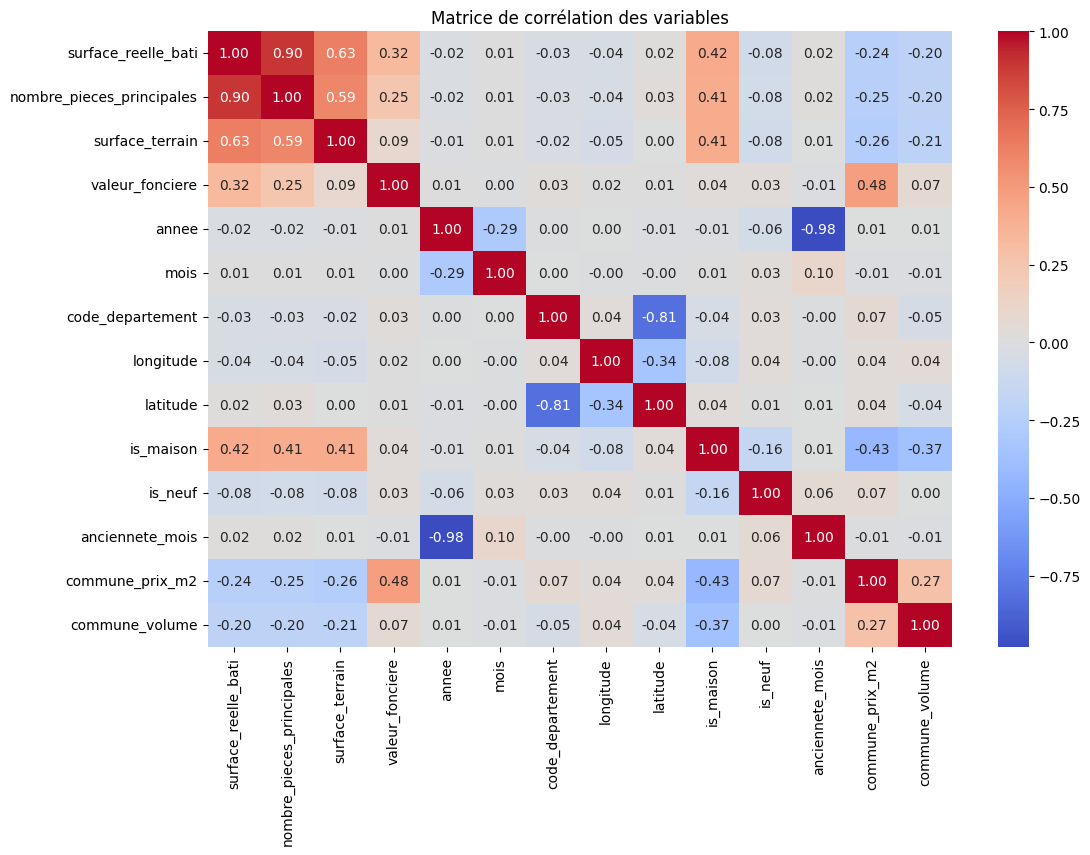

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# On calcule la corrélation uniquement sur les colonnes numériques
corr = df_clean.select_dtypes(include=['number']).corr()

# Affichage de la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation des variables")
plt.show()

## Export dataset

In [66]:
# Sauvegarde du fichier final prêt pour le ML
df_clean.to_csv('dvf_clean_model_ready.csv', index=False)

print("Fichier exporté avec succès sous le nom 'dvf_clean_model_ready.csv'")

Fichier exporté avec succès sous le nom 'dvf_clean_model_ready.csv'
